In [1]:
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import ta as ta_lib

load_dotenv("../.env")

FILE_PATH = os.getenv("forex")

In [2]:
df = pd.read_csv(FILE_PATH, index_col='date', parse_dates=True)

In [3]:
df.columns

Index(['slug', 'open', 'high', 'low', 'close', 'currency'], dtype='object')

In [4]:
df.columns = ['Slug', 'Open', 'High', 'Low', 'Close', 'Currency']
TARGET_COLUMN = 'Close'

In [5]:
df = df[df['Slug'] == 'USD/EUR'].copy()

In [6]:
df.describe

<bound method NDFrame.describe of                Slug      Open     High      Low    Close Currency
date                                                             
2003-12-01  USD/EUR  0.830980  0.83724  0.83056  0.83577      EUR
2003-12-02  USD/EUR  0.836050  0.83710  0.82583  0.82720      EUR
2003-12-03  USD/EUR  0.827130  0.82802  0.82440  0.82488      EUR
2003-12-04  USD/EUR  0.825080  0.83029  0.82345  0.82775      EUR
2003-12-05  USD/EUR  0.827950  0.82878  0.82028  0.82055      EUR
...             ...       ...      ...      ...      ...      ...
2021-08-24  USD/EUR  0.851300  0.85265  0.84999  0.85146      EUR
2021-08-25  USD/EUR  0.850700  0.85262  0.85030  0.85084      EUR
2021-08-26  USD/EUR  0.849401  0.85122  0.84880  0.84930      EUR
2021-08-27  USD/EUR  0.850850  0.85208  0.84720  0.85060      EUR
2021-08-30  USD/EUR  0.847200  0.84840  0.84630  0.84700      EUR

[4582 rows x 6 columns]>

In [7]:
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_date_range)

In [8]:
df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()

In [9]:
df['Slug'] = df['Slug'].ffill()
df['Currency'] = df['Currency'].ffill()

In [10]:
df.isnull().sum()

Slug        0
Open        0
High        0
Low         0
Close       0
Currency    0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Slug        0
Open        0
High        0
Low         0
Close       0
Currency    0
dtype: int64

In [13]:
df['Log_Return'] = np.log(df[TARGET_COLUMN] / df[TARGET_COLUMN].shift(1))

In [14]:
df['ATR'] = ta_lib.volatility.AverageTrueRange(
    high=df['High'], low=df['Low'], close=df['Close'], window=14
).average_true_range()

In [15]:
df['RSI'] = ta_lib.momentum.RSIIndicator(
    close=df['Close'], window=14
).rsi()

In [16]:
macd = ta_lib.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

In [17]:
df['Daily_Range'] = df['High'] - df['Low']
df['Open_Close_Diff'] = df['Close'] - df['Open']

In [18]:
df['Lag_1'] = df[TARGET_COLUMN].shift(1)
df['Lag_5'] = df[TARGET_COLUMN].shift(5)

In [19]:
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['Year'] = df.index.year

In [20]:
df_features = df.drop(columns=['Slug', 'Currency']).dropna()

In [21]:
df_features.isnull().sum()

Open               0
High               0
Low                0
Close              0
Log_Return         0
ATR                0
RSI                0
MACD               0
MACD_Signal        0
Daily_Range        0
Open_Close_Diff    0
Lag_1              0
Lag_5              0
Month              0
DayOfWeek          0
Year               0
dtype: int64

In [22]:
TEST_PERIOD = 180 
TIME_STEP = 60

In [23]:
split_point = len(df_features) - TEST_PERIOD
df_train = df_features[:split_point]
df_test = df_features[split_point:]

In [24]:
y_test_real = df_test[TARGET_COLUMN].values
test_index = df_test.index

In [25]:
FEATURES_XGB = df_features.columns.drop(TARGET_COLUMN).tolist()

In [26]:
X_train_xgb = df_train[FEATURES_XGB]
y_train_xgb = df_train[TARGET_COLUMN]
X_test_xgb = df_test[FEATURES_XGB]

In [27]:
OHLC_FEATURES = ['Open', 'High', 'Low', 'Close', 'RSI', 'MACD', 'ATR', 'Log_Return', 'Lag_1']

In [28]:
scaler_t = MinMaxScaler(feature_range=(0, 1))
scaled_ohlc_data = scaler_t.fit_transform(df_features[OHLC_FEATURES].values)

scaler_y = MinMaxScaler(feature_range=(0, 1))
scaled_y_data = scaler_y.fit_transform(df_features[TARGET_COLUMN].values.reshape(-1, 1))

In [29]:
def create_sequences_multi(X_data, y_data, time_step):
    X, y = [], []
    for i in range(len(X_data) - time_step):
        X.append(X_data[i:(i + time_step), :])
        y.append(y_data[i + time_step, 0])
    return np.array(X), np.array(y)

In [30]:
X_scaled_t, y_scaled_t = create_sequences_multi(scaled_ohlc_data, scaled_y_data, TIME_STEP)

In [31]:
train_len_t = len(df_train) - TIME_STEP
X_train_t = X_scaled_t[:train_len_t]
y_train_t = y_scaled_t[:train_len_t]
X_test_t = X_scaled_t[train_len_t:]

In [32]:
def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0.4):
    norm_1 = LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout
    )(norm_1, norm_1)
    res_1 = inputs + attention_output
    
    norm_2 = LayerNormalization(epsilon=1e-6)(res_1)
    ff_output = Dense(ff_dim, activation="relu")(norm_2)
    ff_output = Dropout(dropout)(ff_output)
    ff_output = Dense(inputs.shape[-1])(ff_output)
    
    return res_1 + ff_output

In [33]:
def build_transformer_model(input_shape):
    inputs = Input(shape=input_shape)
    
    x = transformer_block(inputs, head_size=64, num_heads=4, ff_dim=4, dropout=0.4)
    
    x = GRU(32, return_sequences=False, kernel_regularizer=l2(1e-3))(x) 
    x = Dropout(0.4)(x)
    
    outputs = Dense(1)(x)
    return Model(inputs=inputs, outputs=outputs)

In [34]:
transformer_model = build_transformer_model(X_train_t.shape[1:])
transformer_model.compile(loss="mse", optimizer=Adam(learning_rate=5e-5))

In [35]:
transformer_history = transformer_model.fit(
    X_train_t, y_train_t, epochs=100, batch_size=32, verbose=0
)

In [36]:
pred_scaled_transformer = transformer_model.predict(X_test_t)
pred_transformer = scaler_y.inverse_transform(pred_scaled_transformer).flatten()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [37]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_xgb, y_train_xgb)
pred_xgb = xgb_model.predict(X_test_xgb)

In [38]:
if len(pred_transformer) != len(pred_xgb):
    start_index = len(pred_xgb) - len(pred_transformer)
    pred_xgb_aligned = pred_xgb[start_index:]
else:
    pred_xgb_aligned = pred_xgb

In [39]:
y_test_aligned = y_test_real[-len(pred_transformer):]
test_index_aligned = test_index[-len(pred_transformer):]

In [40]:
pred_ensemble = (pred_transformer + pred_xgb_aligned) / 2

In [41]:
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_xgb = calculate_rmse(y_test_aligned, pred_xgb_aligned)
rmse_transformer = calculate_rmse(y_test_aligned, pred_transformer)
rmse_ensemble = calculate_rmse(y_test_aligned, pred_ensemble)

In [42]:
print(f"RMSE XGBoost: {rmse_xgb:.4f}")
print(f"RMSE trans: {rmse_transformer:.4f}")
print(f"RMSE essemble (Avg): {rmse_ensemble:.4f}")

RMSE XGBoost: 0.0012
RMSE trans: 0.0037
RMSE essemble (Avg): 0.0020


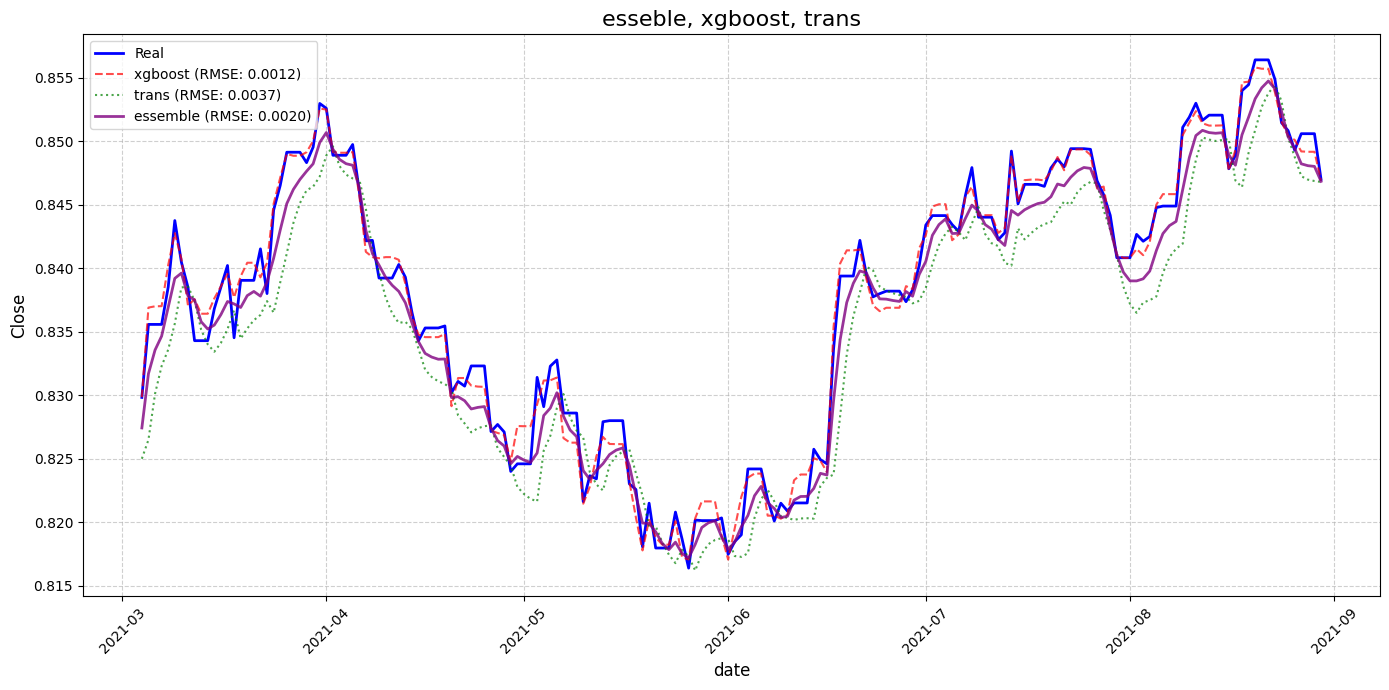

In [43]:
plt.figure(figsize=(14, 7))

plt.plot(test_index_aligned, y_test_aligned, 
         label='Real', color='blue', linewidth=2)
plt.plot(test_index_aligned, pred_xgb_aligned, 
         label=f'xgboost (RMSE: {rmse_xgb:.4f})', color='red', linestyle='--', alpha=0.7)
plt.plot(test_index_aligned, pred_transformer, 
         label=f'trans (RMSE: {rmse_transformer:.4f})', color='green', linestyle=':', alpha=0.7)
plt.plot(test_index_aligned, pred_ensemble, 
         label=f'essemble (RMSE: {rmse_ensemble:.4f})', color='purple', linestyle='-', linewidth=2, alpha=0.8)

plt.title('esseble, xgboost, trans', fontsize=16)
plt.xlabel('date', fontsize=12)
plt.ylabel(f'{TARGET_COLUMN}', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# конф матрицу